# Sioux Falls — multi-factor sensitivity visuals

All visuals for the **statistically valid, sampled** Morris screen produced by
`scripts/testbed/run_multifactor_sensitivity_sioux_falls.py` (Balanced 8 factors,
both targets read from the same pipeline runs).

This notebook only **reads** the driver's outputs under
`results/multifactor_sensitivity/` — it does not re-run the pipeline. If the
outputs are missing, generate them first:

```
python scripts/testbed/run_multifactor_sensitivity_sioux_falls.py -r 4
```

Sections: **(1)** μ\*–σ screening panel · **(2)** tornado ranking ·
**(3)** μ\* with confidence intervals · **(4)** direct-vs-indirect comparison ·
**(5)** dose–response clouds.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


def _find_repo_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / "src" / "resiflow").is_dir():
            return p
    raise RuntimeError("Could not locate repo root (looked for src/resiflow)")


REPO_ROOT = _find_repo_root(Path.cwd())
for sub in ("src", "scripts/visualizations"):
    p = str(REPO_ROOT / sub)
    if p not in sys.path:
        sys.path.insert(0, p)

RESULTS = REPO_ROOT / "results" / "multifactor_sensitivity"
SENS = RESULTS / "sensitivity_analysis"
assert RESULTS.exists(), (
    f"No multifactor results at {RESULTS}.\n"
    "Run: python scripts/testbed/run_multifactor_sensitivity_sioux_falls.py -r 4"
)

samples = pd.read_csv(RESULTS / "samples.csv")
direct = pd.read_csv(SENS / "morris_direct.csv")
indirect = pd.read_csv(SENS / "morris_indirect.csv")

# display name -> samples.csv multiplier column
FACTOR_MAP = {
    "Flood Depth": "flood_depth",
    "Damage Ratio": "damage_ratio",
    "Unit Asset Value": "damage_value",
    "Road Width": "averageWidth",
    "Lanes": "lanes",
    "Demand": "demand_scale",
    "Value of Time": "value_of_time",
    "Closure Threshold": "flood_closure_threshold",
}
TARGETS = {
    "direct": ("Direct damage cost", "direct_damage_usd", direct),
    "indirect": ("Indirect rerouting cost", "rerouting_total_usd", indirect),
}

C_DIRECT, C_INDIRECT, GRID = "#2a78d6", "#e2703a", "#d9d8d2"


def usd(v, _=None):
    v = float(v)
    if abs(v) >= 1e6:
        return f"${v / 1e6:.1f}M"
    if abs(v) >= 1e3:
        return f"${v / 1e3:.0f}K"
    return f"${v:.0f}"


print(f"samples: {len(samples)} runs | "
      f"direct factors: {len(direct)} | indirect factors: {len(indirect)}")
samples.head()

samples: 36 runs | direct factors: 8 | indirect factors: 8


,sample,flood_depth,damage_ratio,damage_value,averageWidth,lanes,demand_scale,value_of_time,flood_closure_threshold,direct_damage_usd,rerouting_total_usd
0,0,2.0,1.5,1.5,0.5,1.5,1.5,0.5,2.0,149349.814924,57722.470304
1,1,2.0,1.5,1.5,0.5,0.5,1.5,0.5,2.0,65176.139250,57722.470304
2,2,2.0,0.5,1.5,0.5,0.5,1.5,0.5,2.0,22597.769894,57722.470304
3,3,2.0,0.5,1.5,0.5,0.5,1.5,0.5,1.0,22597.769894,57722.470304
4,4,1.0,0.5,1.5,0.5,0.5,1.5,0.5,1.0,18510.436875,57722.470304


## 1. Morris μ\*–σ screening panel

The canonical screening view (same figure the driver saves as
`sensitivity_panel.png`), rendered through the shared loader
`viz_data_loaders.plot_sensitivity_panels`. Both axes are **normalised by the
same per-target total** (Σμ\*), so they share one dimensionless scale:
**x = μ\*** (first-order importance), **y = σ** (interactions / nonlinearity).
The dashed line is **μ\* = σ** — points **above** it are interaction /
threshold-dominated (e.g. Flood Depth on the indirect panel), points **below**
it are first-order-dominated.

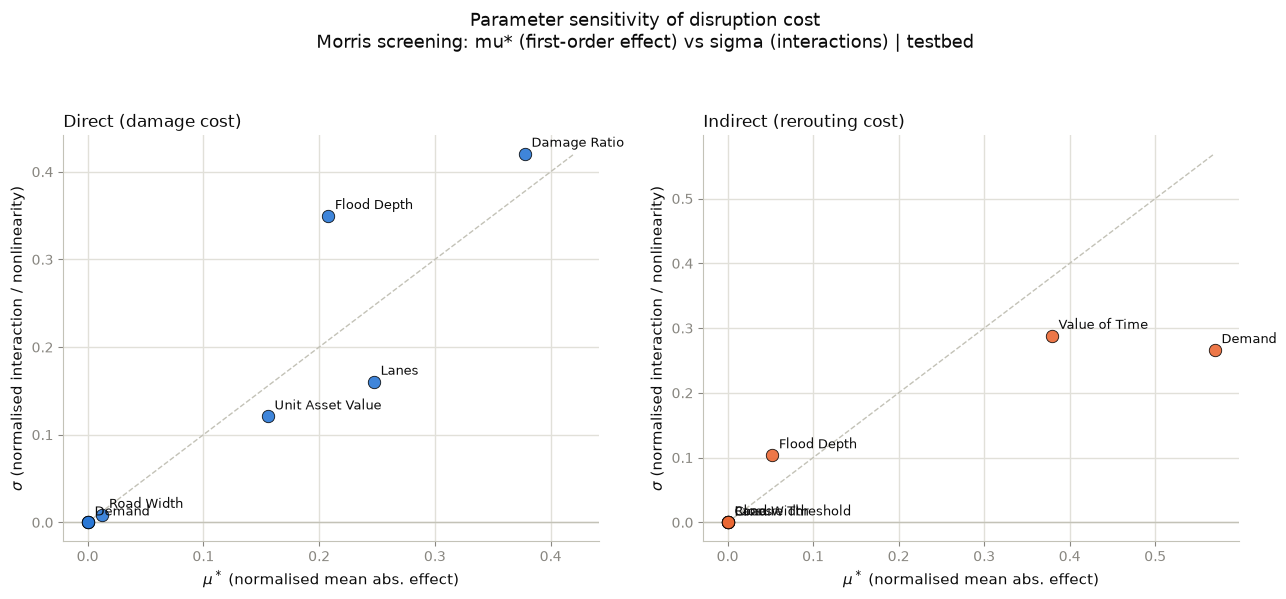

In [2]:
from viz_data_loaders import plot_sensitivity_panels

panel_df = pd.concat(
    [direct.assign(target="direct"), indirect.assign(target="indirect")],
    ignore_index=True,
)
fig, _ = plot_sensitivity_panels(panel_df, variant="toy_sioux_falls")
plt.show()

## 2. Tornado — μ\* ranked

The clearest "what matters most" view: factors sorted by μ\* for each target.

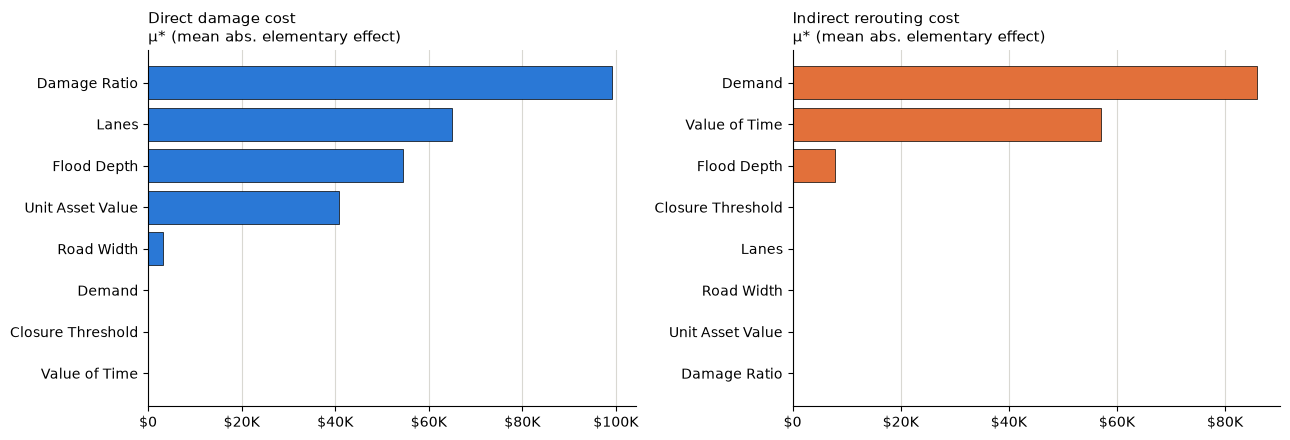

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (key, (title, _col, mdf)) in zip(axes, TARGETS.items()):
    color = C_DIRECT if key == "direct" else C_INDIRECT
    d = mdf.sort_values("S1_abs")
    ax.barh(d["Parameters"], d["S1_abs"], color=color,
            edgecolor="black", linewidth=0.5)
    ax.set_title(f"{title}\nμ* (mean abs. elementary effect)",
                 loc="left", fontsize=11)
    ax.xaxis.set_major_formatter(plt.FuncFormatter(usd))
    ax.xaxis.grid(True, color=GRID)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 3. μ\* with confidence intervals

μ\* per factor with SALib's 95% bootstrap CI (`S1_abs_conf`). At **r = 4** the
intervals are wide — this panel is the honest reminder that the *ranking* is
robust but the *magnitudes* firm up only at higher r.

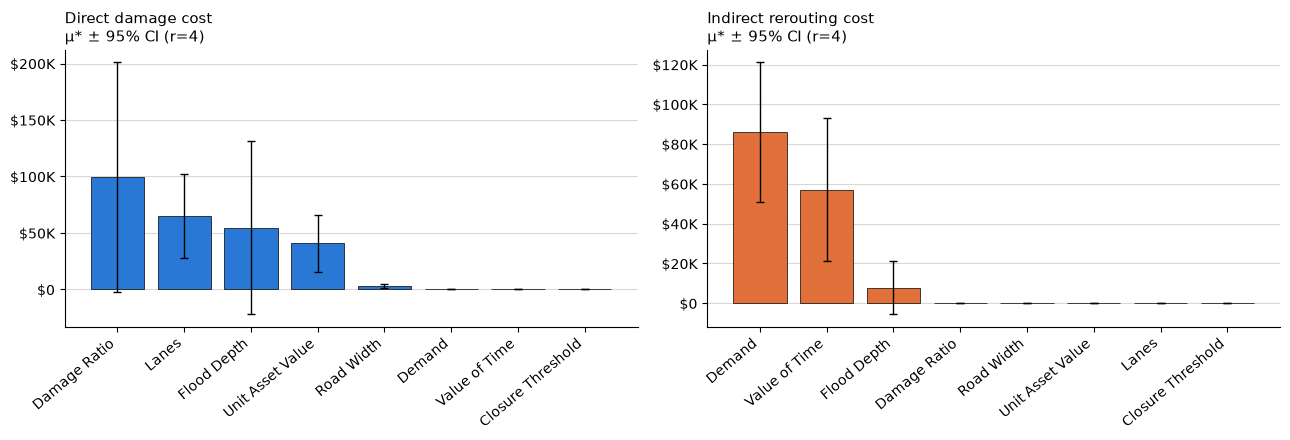

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for ax, (key, (title, _col, mdf)) in zip(axes, TARGETS.items()):
    color = C_DIRECT if key == "direct" else C_INDIRECT
    d = mdf.sort_values("S1_abs", ascending=False)
    x = np.arange(len(d))
    ax.bar(x, d["S1_abs"], yerr=d["S1_abs_conf"], color=color,
           edgecolor="black", linewidth=0.5, capsize=3,
           error_kw={"linewidth": 1})
    ax.set_xticks(x)
    ax.set_xticklabels(d["Parameters"], rotation=40, ha="right")
    ax.set_title(f"{title}\nμ* ± 95% CI (r=4)", loc="left", fontsize=11)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(usd))
    ax.yaxis.grid(True, color=GRID)
    ax.set_axisbelow(True)
    for s in ("top", "right"):
        ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 4. Which factor drives which cost (normalised μ\*)

μ\* normalised to a share **within each target** so the two targets are directly
comparable on one axis. Shows the clean separation: damage-side factors drive
direct cost; demand / value-of-time / flood depth drive indirect cost.

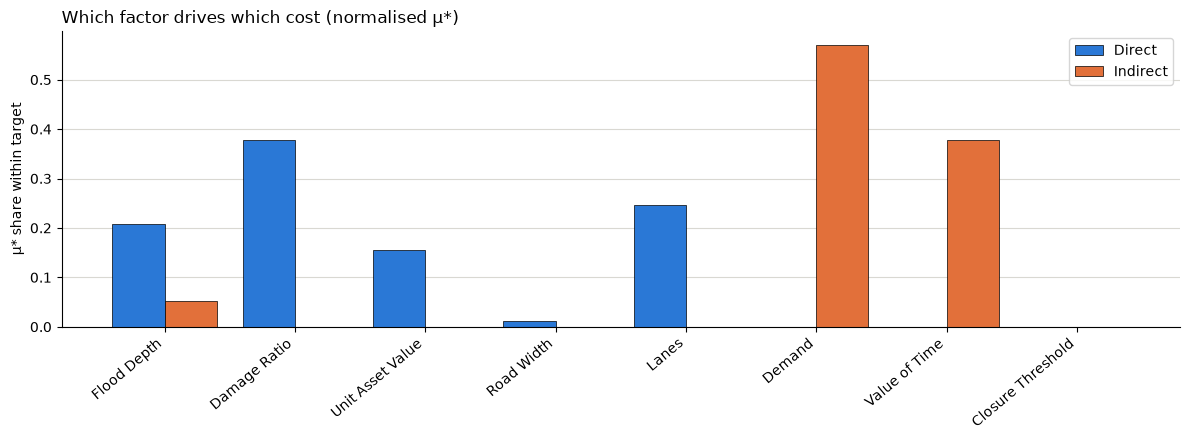

In [5]:
dn = direct.set_index("Parameters")["S1_abs"]
dn = dn / dn.sum() if dn.sum() else dn
ind = indirect.set_index("Parameters")["S1_abs"]
ind = ind / ind.sum() if ind.sum() else ind

order = list(FACTOR_MAP.keys())
dn = dn.reindex(order).fillna(0.0)
ind = ind.reindex(order).fillna(0.0)

x = np.arange(len(order))
w = 0.4
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.bar(x - w / 2, dn.values, w, label="Direct", color=C_DIRECT,
       edgecolor="black", linewidth=0.5)
ax.bar(x + w / 2, ind.values, w, label="Indirect", color=C_INDIRECT,
       edgecolor="black", linewidth=0.5)
ax.set_xticks(x)
ax.set_xticklabels(order, rotation=40, ha="right")
ax.set_ylabel("μ* share within target")
ax.set_title("Which factor drives which cost (normalised μ*)", loc="left")
ax.legend()
ax.yaxis.grid(True, color=GRID)
ax.set_axisbelow(True)
for s in ("top", "right"):
    ax.spines[s].set_visible(False)
fig.tight_layout()
plt.show()

## 5. Dose–response clouds

Cost vs each factor's multiplier `m`, one panel per factor. **Note:** points come
from the Morris trajectory design (other factors also move between trajectories),
so each panel is a *marginal cloud*, not a clean 1-D sweep — but the trend and,
crucially, **threshold shapes** (e.g. Flood Depth's jump on the indirect target)
are still visible. Inert factors show a flat cloud.

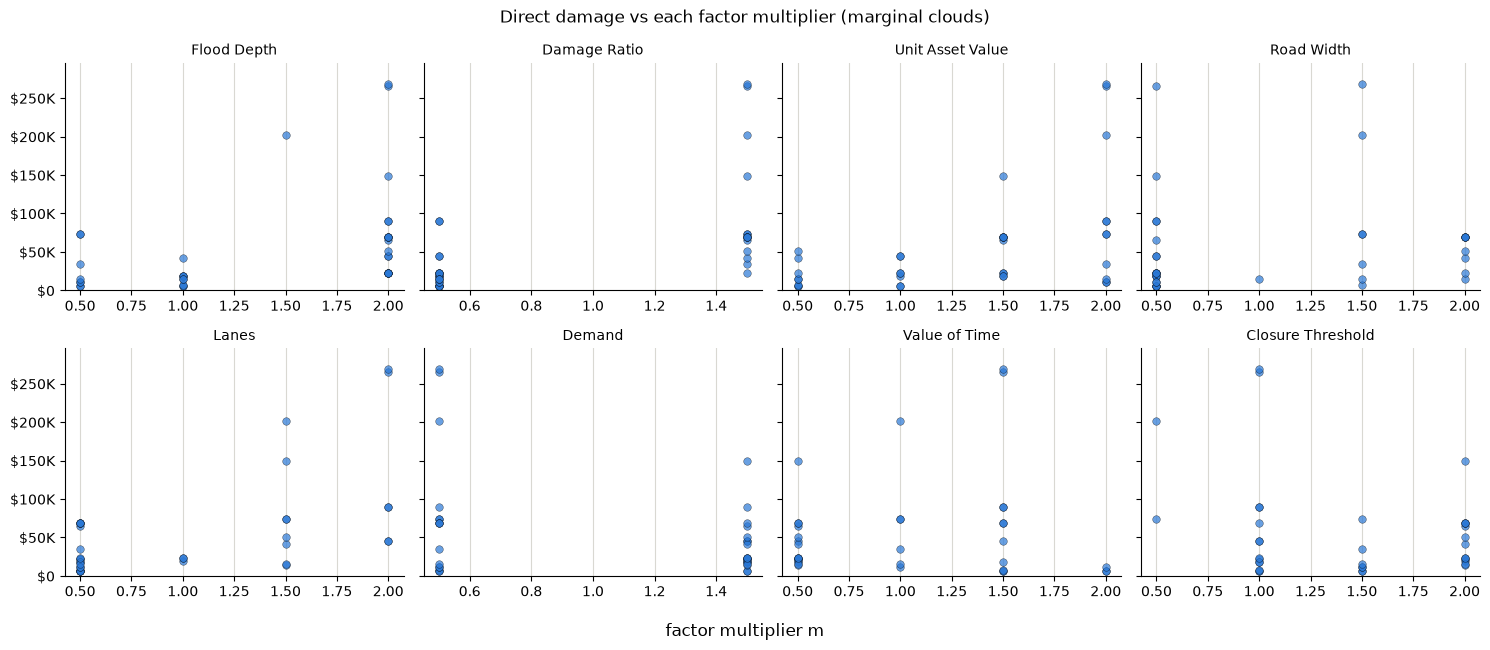

In [6]:
def dose_grid(cost_col, color, title):
    factors = list(FACTOR_MAP.keys())
    fig, axes = plt.subplots(2, 4, figsize=(15, 6.5), sharey=True)
    ymax = float(samples[cost_col].max()) * 1.1 or 1.0
    for ax, name in zip(axes.ravel(), factors):
        col = FACTOR_MAP[name]
        ax.scatter(samples[col], samples[cost_col], s=30, alpha=0.7,
                   color=color, edgecolor="black", linewidth=0.3)
        ax.set_title(name, fontsize=10)
        ax.set_ylim(0, ymax)
        ax.yaxis.set_major_formatter(plt.FuncFormatter(usd))
        ax.xaxis.grid(True, color=GRID)
        ax.set_axisbelow(True)
        for s in ("top", "right"):
            ax.spines[s].set_visible(False)
    fig.suptitle(title, fontsize=12)
    fig.supxlabel("factor multiplier m")
    fig.tight_layout()
    return fig


dose_grid("direct_damage_usd", C_DIRECT,
          "Direct damage vs each factor multiplier (marginal clouds)")
plt.show()

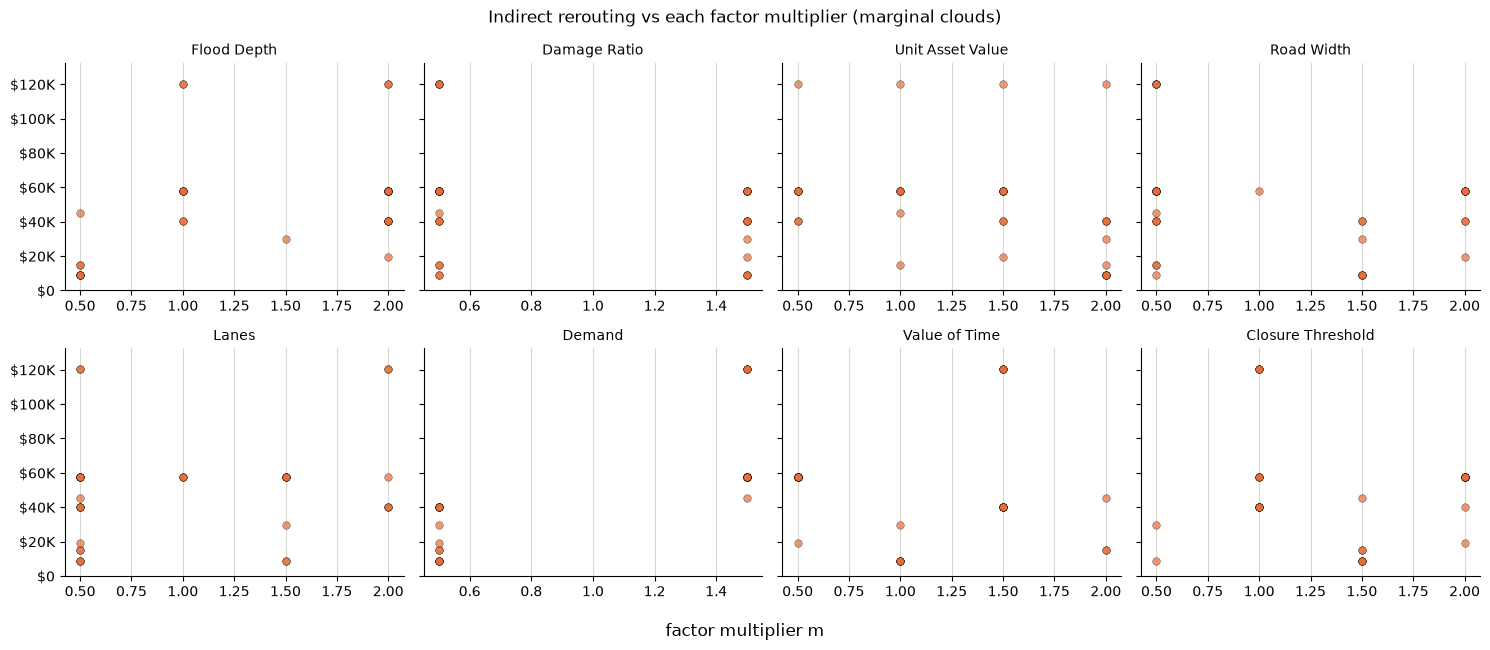

In [7]:
dose_grid("rerouting_total_usd", C_INDIRECT,
          "Indirect rerouting vs each factor multiplier (marginal clouds)")
plt.show()